# The Narrative Structure of the _Popol Wuj_:<br/>A Statistical Approach

Rafael C. Alvarado | Spring 2025

# Overview



# Import libraries

In [119]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly_express as px
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF, PCA
from sklearn.cluster import KMeans

In [120]:
import sys; sys.path.append("../../local_lib/")

from hac2 import HAC
from heatmap import plot_grid, plot_map, CorrelationHeatMap as CHM

# Set hyperparameters

In [121]:
px_template = 'plotly_white'

# Number of equal size chunks to divide the TOKEN table
n_chunks = 50

# Use if parsing strings of Mayan
# token_pattern = r"(?u)\b\w[\w']*\b"

# These are used with CounterVectorizer
min_ngram = 1
max_ngram = 1

# The limit below which words will be excluded from models
dh_thresh_agg = 'mean' # Use 'median' for much less severe cut

# Read in CHAP and TOKEN

In [122]:
CHAP = pd.read_csv("christenson-CHAP-with-text.csv").set_index("chap_num")
TOKEN = pd.read_csv("christenson-TOKEN_QUC.csv").set_index(['chap_num','line_num','token_num'])

# Create CHUNK

In [123]:
TOKEN['chunk_id'] = (
    pd.DataFrame(np.array_split(TOKEN.index, n_chunks))
    .stack()
    .reset_index()
    .level_0
    .values + 1
)

In [124]:
TOKEN.head(10)

token_str term_str  chunk_id
chap_num line_num token_num                             
1        1        0               ARE      are         1
                  1                 U        u         1
                  2                XE       xe         1
                  3              OJER     ojer         1
                  4              TZIJ     tzij         1
         2        0             Waral    waral         1
                  1            K'iche   k'iche         1
                  2                 u        u         1
                  3               b'i      b'i         1
         3        0             WARAL    waral         1

In [125]:
CHUNK = (
    TOKEN
    .groupby('chunk_id')
    .term_str
    .count()
    .to_frame('n_tokens')
)

In [126]:
CHUNK.value_counts('n_tokens')

n_tokens
587    18
588    13
586    10
585     5
584     4
Name: count, dtype: int64

In [127]:
# CHUNK

# Create CHUNK_TO_CHAP

Chunk to Chapters Index

In [128]:
CHUNK_TO_CHAP = (
    TOKEN
    .reset_index()
    .groupby(['chunk_id'])
    .chap_num
    .apply(lambda x: sorted(list(set(x))))
    .apply(pd.Series).stack()
    .to_frame('chap_num')
    .sort_index()
).join(CHAP.chap_title, on='chap_num')
CHUNK_TO_CHAP.index.names = ['chunk_id', 'chap_ord']
CHUNK_TO_CHAP['chap_label'] = CHUNK_TO_CHAP.chap_num.astype(int).astype(str) + ': ' + CHUNK_TO_CHAP.chap_title
CHUNK_TO_CHAP.chap_num = CHUNK_TO_CHAP.chap_num.astype(int)

In [129]:
CHUNK_TO_CHAP

chap_num                                       chap_title  \
chunk_id chap_ord                                                              
1        0                1                                         Preamble   
         1                2                             The Primordial World   
         2                3                        The Creation of the Earth   
2        0                3                        The Creation of the Earth   
         1                4                      The Creation of the Animals   
...                     ...                                              ...   
50       1               83                      The Dynasty of Nihaib Lords   
         2               84             The Great Houses of the Nihaib Lords   
         3               85                 The Dynasty of Ahau Quiché Lords   
         4               86        The Great Houses of the Ahau Quiché Lords   
         5               87  The Three Great Stewards as Mothers of the Word   

                                                          chap_label  
chunk_id chap_ord                                                     
1        0                                               1: Preamble  
         1                                   2: The Primordial World  
         2                              3: The Creation of the Earth  
2        0                              3: The Creation of the Earth  
         1                            4: The Creation of the Animals  
...                                                              ...  
50       1                           83: The Dynasty of Nihaib Lords  
         2                  84: The Great Houses of the Nihaib Lords  
         3                      85: The Dynasty of Ahau Quiché Lords  
         4             86: The Great Houses of the Ahau Quiché Lords  
         5         87: The Three Great Stewards as Mothers of the...  

[136 rows x 3 columns]

Chapter Labels for Chunks

In [130]:
CHUNK['short_label'] = CHUNK_TO_CHAP.groupby('chunk_id').chap_num.apply(lambda x: '[' + str(x.name) + '] ' + ' '.join(map(str,x)))
CHUNK['long_label'] = CHUNK_TO_CHAP.groupby('chunk_id').chap_label.apply(lambda x: '[' + str(x.name) + '] ' + ' '.join(map(str, x)))

In [131]:
CHUNK.head()

,n_tokens,short_label,long_label
chunk_id,,,
1,588,[1] 1 2 3,[1] 1: Preamble 2: The Primordial World 3: The...
2,587,[2] 3 4 5 6,[2] 3: The Creation of the Earth 4: The Creati...
3,588,[3] 6 7 8,[3] 6: The Creation of the Mud Person 7: The C...
4,587,[4] 8 9,[4] 8: The Fall of the Effigies of Carved Wood...
5,586,[5] 9 10 11,[5] 9: The Pride of Seven Macaw Before the Daw...


# Create BOW for CHAP and CHUNK

In [132]:
BOW_CHAP = TOKEN.groupby(['chap_num', 'term_str']).term_str.count()
BOW_CHUNK = TOKEN.groupby(['chunk_id', 'term_str']).term_str.count()

# Create CTM

In [133]:
CTM = BOW_CHUNK.unstack(fill_value=0)

In [134]:
CTM.sample(10).T.sample(10).T.style.background_gradient(axis=None, cmap='Blues')

term_str,tujala,chik'ulwachix,nimarisay,chiqakamisaj,ch'ob,chuxib'ij,xchiqake'j,xech'akatajik,chik'amowik,yoq'otaj
chunk_id,,,,,,,,,,
7,0,0,0,1,0,0,0,0,0,0
12,0,0,0,0,0,0,0,1,0,0
32,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
31,0,0,0,0,2,0,0,0,0,0
26,0,0,0,0,0,0,0,0,0,0
16,0,0,0,0,0,0,0,0,0,0
37,0,0,0,0,0,0,0,0,0,0


# Extract VOCAB

In [135]:
VOCAB = CTM.sum().to_frame('n')
VOCAB.index.name = 'term_str'
VOCAB['grams'] = VOCAB.apply(lambda x: len(x.name.split()), axis=1)

In [136]:
VOCAB

,n,grams
term_str,,
a,36,1
a'on,2,1
ab'aj,31,1
ab'ajil,1,1
ab'anel,1,1
...,...,...
yoq'otajinaq,1,1
yujuj,2,1
yuq,1,1


# Compute DFIDF

In [137]:
VOCAB['df'] = CTM.astype(bool).sum()
VOCAB['dp'] = VOCAB.df / n_chunks
VOCAB['dh'] = VOCAB.dp * np.log2(1/VOCAB.dp)

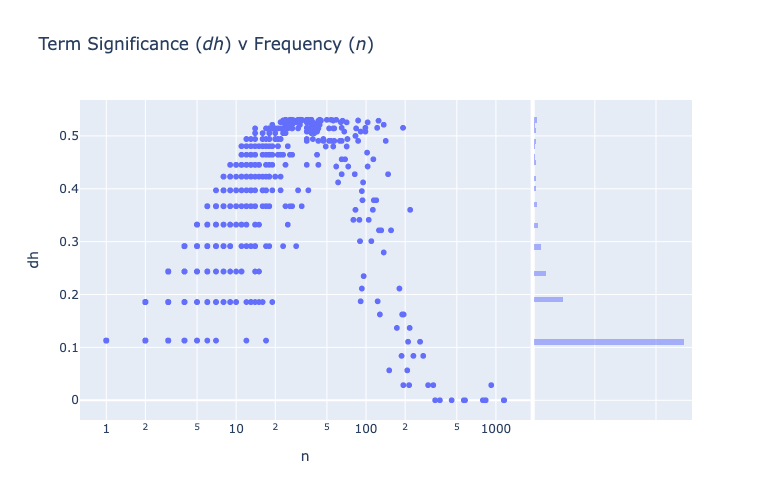

In [138]:
px.scatter(VOCAB.reset_index(), 'n', 'dh', 
           log_x=True, 
           width=750, height=500,
           hover_name='term_str',
           marginal_y='histogram',
          title="Term Significance (<i>dh</i>) v Frequency (<i>n</i>)")

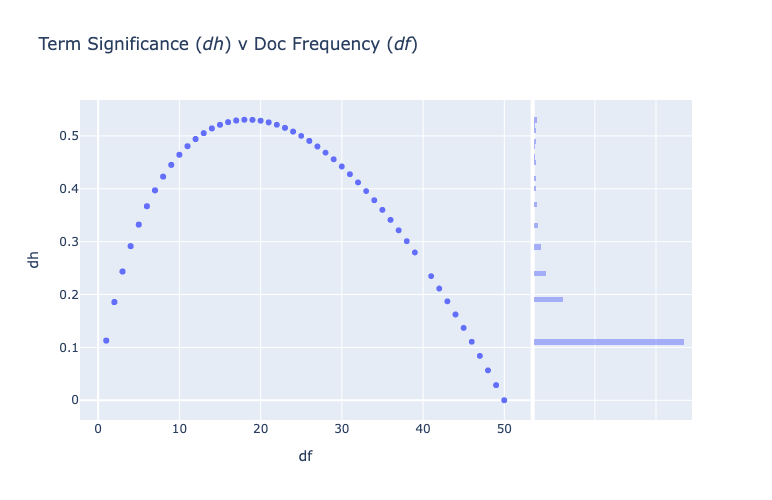

In [139]:
px.scatter(VOCAB.reset_index(), 'df', 'dh', 
           log_x=False, 
           width=750, height=500,
           hover_name='term_str',
           marginal_y='histogram',
          title="Term Significance (<i>dh</i>) v Doc Frequency (<i>df</i>)")

In [140]:
VOCAB.describe()

,n,grams,df,dp,dh
count,3721.000000,3721.0,3721.000000,3721.000000,3721.000000
mean,7.882558,1.0,3.020156,0.060403,0.171569
std,46.479183,0.0,6.058219,0.121164,0.107282
min,1.000000,1.0,1.000000,0.020000,0.000000
25%,1.000000,1.0,1.000000,0.020000,0.112877
50%,1.000000,1.0,1.000000,0.020000,0.112877
75%,3.000000,1.0,2.000000,0.040000,0.185754
max,1161.000000,1.0,50.000000,1.000000,0.530615


# Define stopwords

In [141]:
max_entropy = VOCAB.dh.agg(dh_thresh_agg)

In [142]:
dh_thresh_agg, max_entropy

('mean', 0.17156937513598833)

In [143]:
VOCAB['stop'] = VOCAB.dh < max_entropy

In [144]:
VOCAB[VOCAB.stop == False]

,n,grams,df,dp,dh,stop
term_str,,,,,,
a,36,1,19,0.38,0.530453,False
a'on,2,1,2,0.04,0.185754,False
ab'aj,31,1,18,0.36,0.530615,False
ab'ix,6,1,2,0.04,0.185754,False
achb'ilay,2,1,2,0.04,0.185754,False
...,...,...,...,...,...,...
yaki,7,1,4,0.08,0.291508,False
yakolatam,2,1,2,0.04,0.185754,False
yamanik,5,1,5,0.10,0.332193,False


In [145]:
'Number of significant terms', VOCAB[~VOCAB.stop].shape[0]

('Number of significant terms', 1237)

In [146]:
'Number of rejected words', len(VOCAB[VOCAB.stop]) 

('Number of rejected words', 2484)

In [147]:
'Percent VOCAB used', round((len(VOCAB[~VOCAB.stop]) / len(VOCAB)), 2) * 100

('Percent VOCAB used', 33.0)

# Compute TFIDF over non-stopwords

We weight the significance of words in each chunk using TFIDF.

TFIDF is an established method for estimating the significance of a word in a context by weighing its local frequency in a context against its global frequency in the corpus.

- To the degree that a word is frequent in a specific context and the general corpus, it is not considered siginficant.
- To the degree that a word is frequent in a specific context and infrequenct in the general corpus, it is considered significant.

In [148]:
CTMX = CTM[VOCAB[~VOCAB.stop].index]

In [149]:
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
TFIDF = pd.DataFrame(tfidf_engine.fit_transform(CTMX).toarray(), columns=CTMX.columns, index=CTMX.index)    

In [150]:
TFIDF.sample(10).sort_index().T.sample(5).sort_index().T.style.background_gradient(axis=None, cmap='YlGnBu')

term_str,kab'al,lolmet,quk,ril,saqi
chunk_id,,,,,
6,0.000000,0.000000,0.000000,0.000000,0.108193
15,0.000000,0.000000,0.000000,0.000000,0.000000
16,0.000000,0.000000,0.041739,0.000000,0.000000
18,0.000000,0.000000,0.000000,0.000000,0.000000
22,0.000000,0.000000,0.000000,0.000000,0.024244
24,0.000000,0.000000,0.000000,0.060688,0.000000
30,0.000000,0.000000,0.047179,0.000000,0.000000
33,0.000000,0.000000,0.000000,0.000000,0.000000
36,0.000000,0.000000,0.000000,0.000000,0.064102


# Cluster CHUNK docs by TFIDF
We generate a square matrix of documents by documents showing pairwise similarities.

In [151]:
TFIDF_SIM = pd.DataFrame(cosine_similarity(TFIDF), index=TFIDF.index)

In [152]:
tfidf_hac = HAC(TFIDF_SIM, labels=CHUNK['short_label'].to_list())

In [153]:
tfidf_hac.get_sims()
tfidf_hac.get_tree()

In [154]:
TREE = pd.DataFrame(tfidf_hac.TREE, columns=['i','j','d','n'])

# Choose cluster cut-off

Play with threshold.\
Each cut-off highlights different parts.

<Figure size 640x480 with 0 Axes>

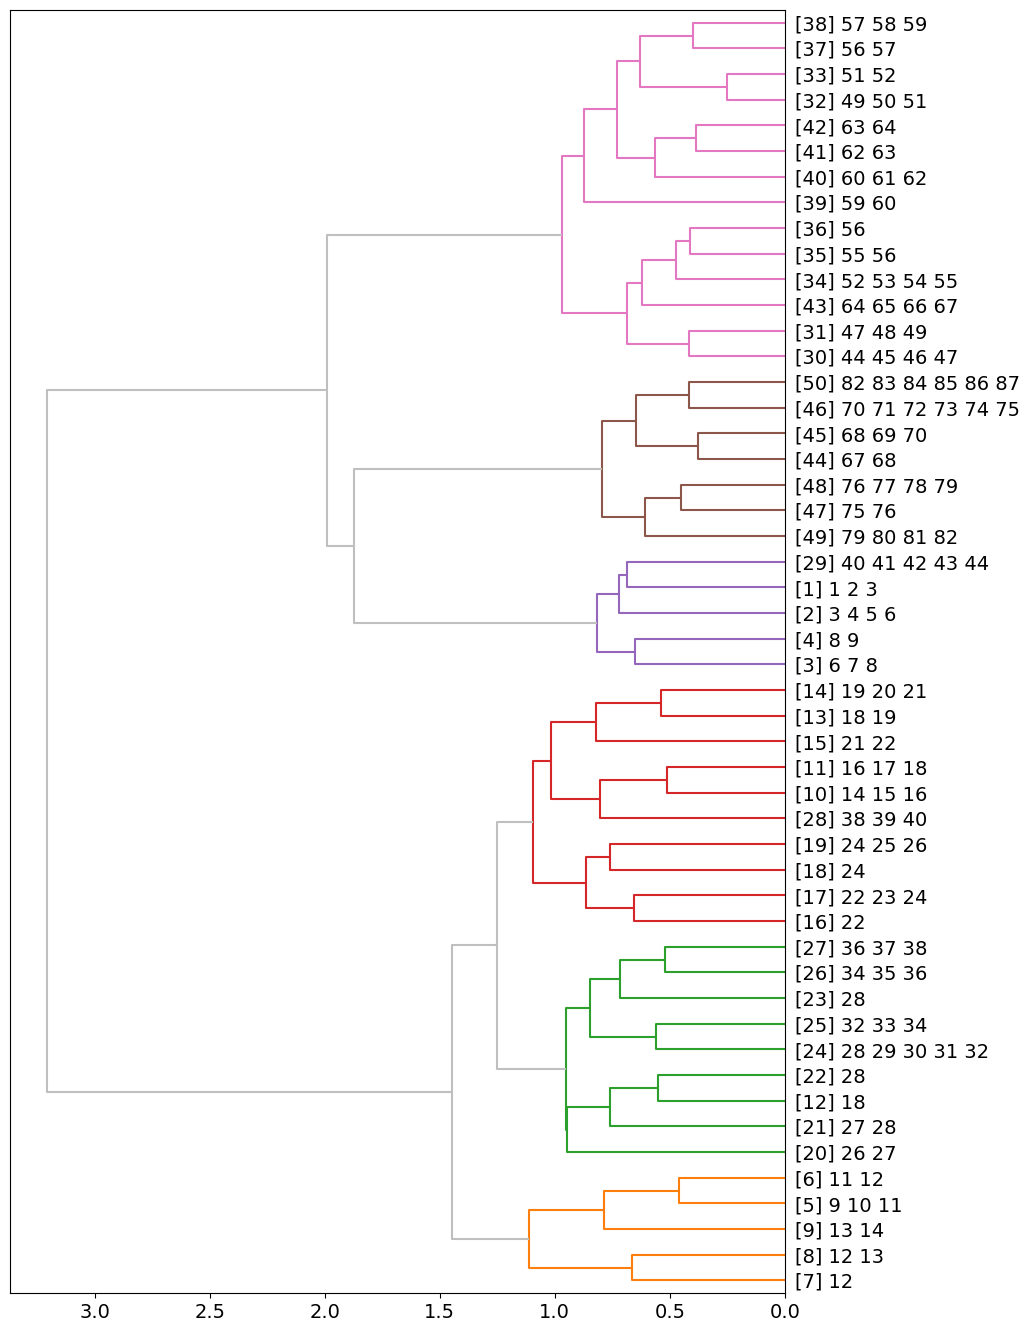

In [155]:
tfidf_hac.color_thresh = 1.2
tfidf_hac.plot_tree()

# View heatmap of document clusters

A heatmap of the same space provides some insight into the nature of the clusters.

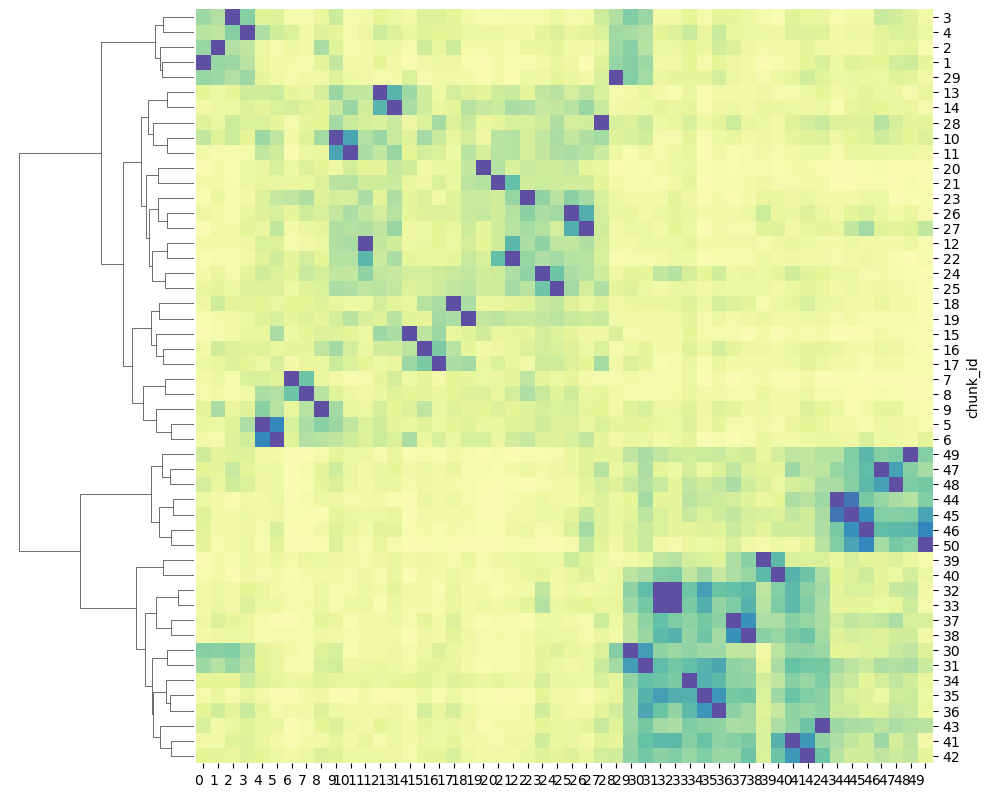

In [156]:
fig = sns.clustermap(TFIDF_SIM,
               method='ward', metric='euclidean',
               cmap='Spectral', center=0, cbar_pos=None, 
               col_cluster=False, robust=True, 
               xticklabels=True, yticklabels=True)
plt.setp(fig.ax_heatmap.get_xticklabels(), rotation=0, ha="right")
fig.ax_col_dendrogram.set_visible(False)

**Interpretation**

- Two main groups.
- Visual inspection shows this corresponds to the first and second halves of the book consistent with how the text is divided by all editions.
- The exception is the group containing chs 1-8 and 39-46 -- this group reflects the theme of creation, which begins both the first and second halves.
- This "echo" marks are thematic touch point.

# Apply cluseter labels to chunks

In [157]:
tfidf_hac.get_cluster_labels()

In [158]:
CHUNK['cluster_label'] = tfidf_hac.CLUSTER_LABELS

In [159]:
TOKEN = TOKEN.join(CHUNK.cluster_label, on="chunk_id")

# Label chapters with clusters

In [160]:
CHAP['cluster_label'] = (
    TOKEN
    .reset_index()
    .value_counts(['chap_num','cluster_label'])
    .unstack(fill_value=0)
    .idxmax(1)
)

In [161]:
# CHAP['cluster_label'] = (
#     TOKEN
#     .groupby(['chap_num','cluster_label'])
#     .cluster_label
#     .count()
#     .unstack(fill_value=0)
#     .idxmax(1)
# )

# Create CLUSTER

In [162]:
CLUSTER = CHUNK.cluster_label.value_counts().to_frame('n_chunks')

In [163]:
CLUSTER

,n_chunks
cluster_label,
4,14
3,10
2,9
5,7
6,5
1,5


# Add order to CLUSTER

In [164]:
labels = {}
ord = 0
for lbl in CHUNK.sort_index().cluster_label.values:
    if lbl not in labels:
        ord += 1
        labels[lbl] = ord

In [165]:
CLUSTER['ord'] = pd.Series(labels)

In [166]:
CLUSTER.sort_values('ord')

,n_chunks,ord
cluster_label,,
6,5,1
1,5,2
3,10,3
2,9,4
4,14,5
5,7,6


# Create CLUSTER_TFIDF model

**Cluster label glosses**

We find significant words for each cluster based on mean TFIDF grouping by cluster.

This also creates a model from the labels; that is, each cluster label is associated with a distribution over words.

In [167]:
label_col = "cluster_label"
CLUSTER_TFIDF = (
    TFIDF
    .join(CHUNK[label_col])
    .groupby(label_col)
    .mean()
)

In [168]:
CLUSTER_TFIDF.T.sample(5).sort_index().T.style.background_gradient(axis=None)

,kab'ij,kixcha,nik'wachinel,rach,yakolatam
cluster_label,,,,,
1,0.007927,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.020251,0.005827,0.000000,0.000000
3,0.004557,0.013913,0.005225,0.000000,0.000000
4,0.000000,0.009755,0.000000,0.003036,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.011543
6,0.000000,0.006934,0.018001,0.027827,0.000000


In [169]:
VOCAB['max_cluster'] = CLUSTER_TFIDF.idxmax()

In [170]:
CLUSTER['gloss'] = CLUSTER_TFIDF.idxmax(1)
CLUSTER['top_terms'] = CLUSTER_TFIDF.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(7).index), axis=1)

In [171]:
CLUSTER

,n_chunks,ord,gloss,top_terms
cluster_label,,,,
4,14,5,b'alam,"b'alam, amaq, tojil, kitze, majukutaj, aj, aq'ab"
3,10,3,junajpu,"junajpu, q'apoj, chowen, kati't, che, b'atz, kame"
2,9,4,xib'alb'a,"xib'alb'a, kame, xcha, b'a, k'ajolab, k'ate, naqi"
5,7,6,ajaw,"ajaw, ajawab, tinamit, aj, pop, nim, k'iche"
6,5,1,kaj,"kaj, b'it, winaq, tz'aq, ulew, tio'jil, aj"
1,5,2,kaqix,"kaqix, k'ajolab, sipakna, wuqub, jul, kab'raqa..."


# Apply CLUSTER_TFIDF model to TOKEN

**Group by CHUNK**

In [172]:
CHUNK['max_cluster'] = (
    TOKEN
    .join(CLUSTER_TFIDF.T, on='term_str')
    .dropna()
    .groupby('chunk_id')[CLUSTER.index]
    .mean()
    .idxmax(1)
)
CHUNK['max_cluster_gloss'] = CHUNK.max_cluster.map(CLUSTER.gloss)

In [173]:
CHUNK[['long_label', 'cluster_label', 'max_cluster','max_cluster_gloss']].style.background_gradient(cmap="YlGnBu")

,long_label,cluster_label,max_cluster,max_cluster_gloss
chunk_id,,,,
1,[1] 1: Preamble 2: The Primordial World 3: The Creation of the Earth,6,6,kaj
2,[2] 3: The Creation of the Earth 4: The Creation of the Animals 5: The Fall of the Animals 6: The Creation of the Mud Person,6,6,kaj
3,[3] 6: The Creation of the Mud Person 7: The Creation of the Effigies of Carved Wood 8: The Fall of the Effigies of Carved Wood,6,6,kaj
4,[4] 8: The Fall of the Effigies of Carved Wood 9: The Pride of Seven Macaw Before the Dawn,6,6,kaj
5,[5] 9: The Pride of Seven Macaw Before the Dawn 10: The Fall of Seven Macaw and His Sons 11: The Defeat of Seven Macaw,1,1,kaqix
6,[6] 11: The Defeat of Seven Macaw 12: The Deeds of Zipacna and the Four Hundred Boys,1,1,kaqix
7,[7] 12: The Deeds of Zipacna and the Four Hundred Boys,1,1,kaqix
8,[8] 12: The Deeds of Zipacna and the Four Hundred Boys 13: The Defeat of Zipacna,1,1,kaqix
9,[9] 13: The Defeat of Zipacna 14: The Defeat of Cabracan,1,1,kaqix


No difference. 

**Group by CHAP**

In [174]:
CHAP['max_cluster'] = (
    TOKEN
    .join(CLUSTER_TFIDF.T, on='term_str')
    .dropna()
    .groupby('chap_num')[CLUSTER.index]
    .mean()
    .idxmax(1)
)
CHAP['max_cluster_gloss'] = CHAP.max_cluster.map(CLUSTER.gloss)

In [175]:
CHAP[['chap_title', 'cluster_label', 'max_cluster', 'max_cluster_gloss']].style.background_gradient(cmap="YlGnBu")

,chap_title,cluster_label,max_cluster,max_cluster_gloss
chap_num,,,,
1,Preamble,6,6,kaj
2,The Primordial World,6,6,kaj
3,The Creation of the Earth,6,6,kaj
4,The Creation of the Animals,6,6,kaj
5,The Fall of the Animals,6,6,kaj
6,The Creation of the Mud Person,6,6,kaj
7,The Creation of the Effigies of Carved Wood,6,6,kaj
8,The Fall of the Effigies of Carved Wood,6,6,kaj
9,The Pride of Seven Macaw Before the Dawn,6,6,kaj


In [176]:
# CHAP_THETA = CHAP.groupby(['chap_num', 'max_cluster']).max_cluster.count().unstack(fill_value=0)

In [177]:
# fig = sns.clustermap(CHAP_THETA.T, 
#                      cmap='Spectral', method='ward',
#                      cbar_pos=None, center=0, 
#                      row_cluster=True, 
#                      col_cluster=False,
#                     figsize=(12,3))

# Apply PCA to TFIDF

PCA sheds light on the relationship between the clusters.

We add $1$ to $k$ if odd to ensure we have pairs to display.

In [178]:
X = TFIDF

In [179]:
n_comps = 5
pca_engine = PCA(n_components=5)
PCAX = pd.DataFrame(pca_engine.fit_transform(X), index=X.index)
PCAX.index.name = 'chunk_id'
LOADINGS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_), index = X.columns)
LOADINGS.index.name = 'term_str'

# Visualize compontents and clusters

In [180]:
X0 = CHUNK.join(PCAX)

def plot_pca(x, y):

    px.scatter(X0, x, y, 
        text=X0.index, 
        height=850, width=950, 
        color=X0.max_cluster_gloss,
        size = [1 for i in range(len(X0))],
        template=px_template,
        marginal_x='box', 
        marginal_y='box').show()

    quantile = .99
    A = LOADINGS.loc[np.abs(LOADINGS[x]) >= np.abs(LOADINGS[x]).quantile(quantile), x]
    B = LOADINGS.loc[np.abs(LOADINGS[y]) >= np.abs(LOADINGS[y]).quantile(quantile), y]    
    C = pd.concat([A,B], axis=1).index
    
    px.scatter(LOADINGS.loc[C].join(VOCAB), x, y, 
        title=f"Quantile {quantile} Loadings for {x} and {y}",
        opacity=.5,
        text=C, 
        size='n',
        template=px_template,
        height=850, width=950).show()
    

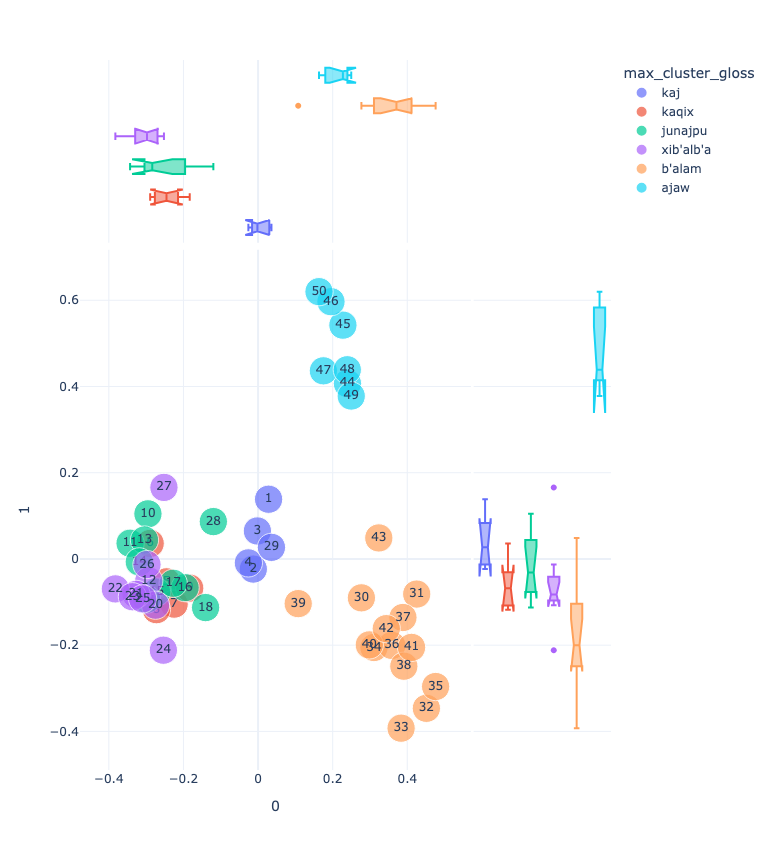

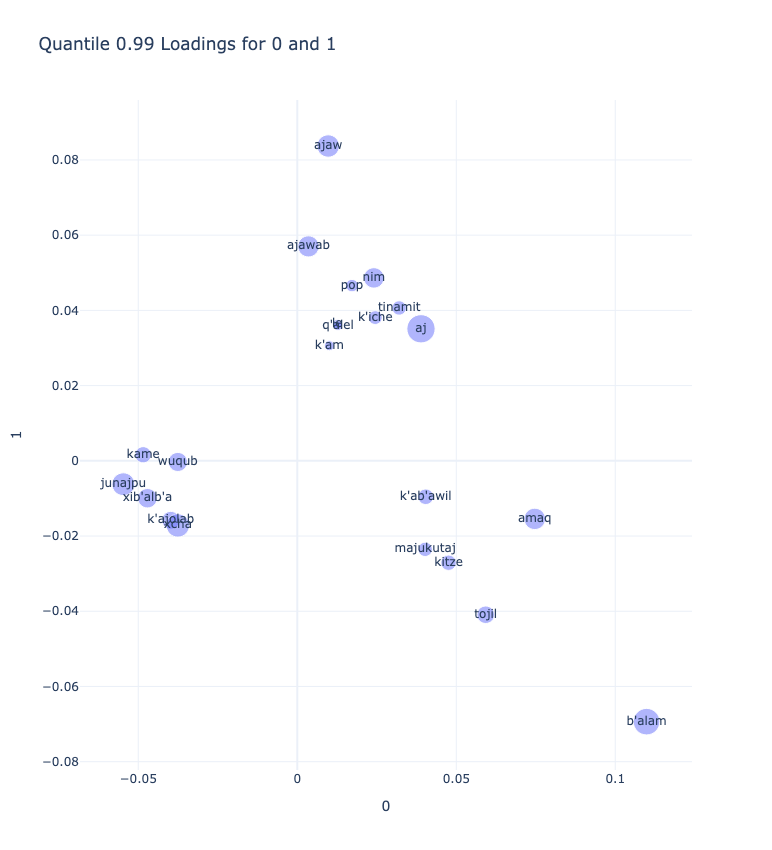

In [181]:
plot_pca(0,1)

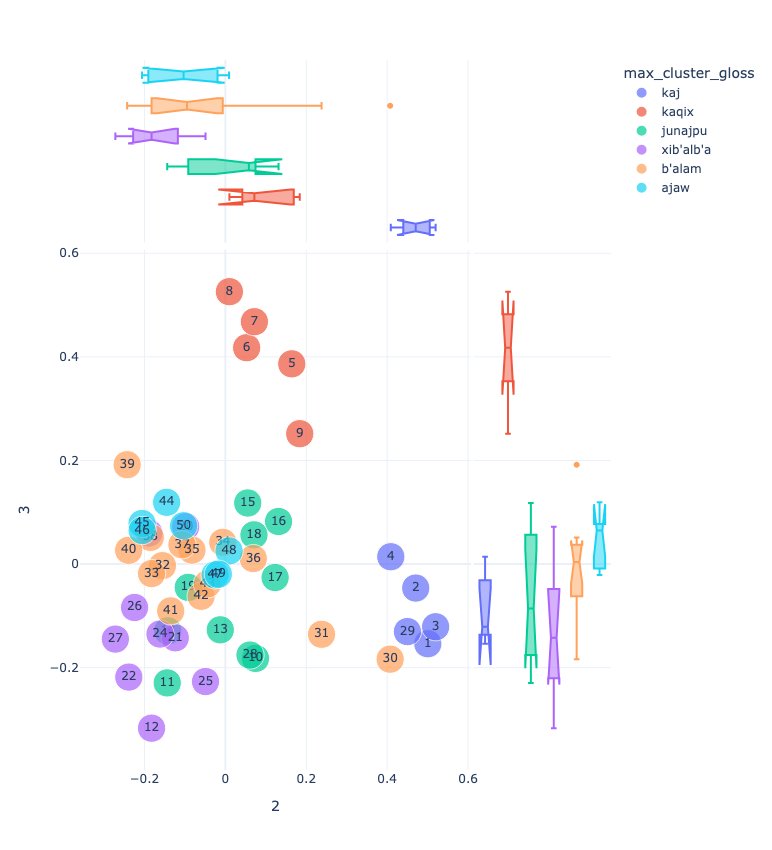

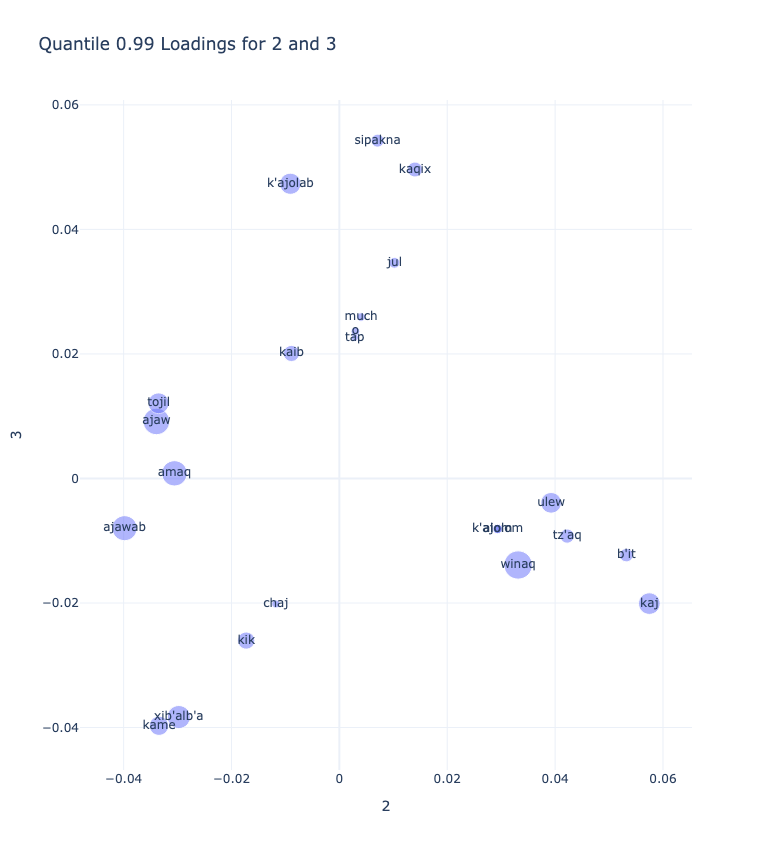

In [182]:
plot_pca(2,3)

In [183]:
# def plot_box(comp=0):
#     plt.figure(figsize=(8, 6))
#     sns.boxplot(data=X0, x='max_cluster_gloss', y=comp)
#     plt.title(f'PC{comp}')
#     plt.xlabel('Cluster Gloss')
#     plt.ylabel('Component Value')
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

In [184]:
def comp_box(comp_id):
    px.box(X0,
           x=comp_id,
           y='max_cluster_gloss',
           color='max_cluster_gloss', 
           template=px_template,
           # height=400, width=600, 
           title=f'PC {i}').show()

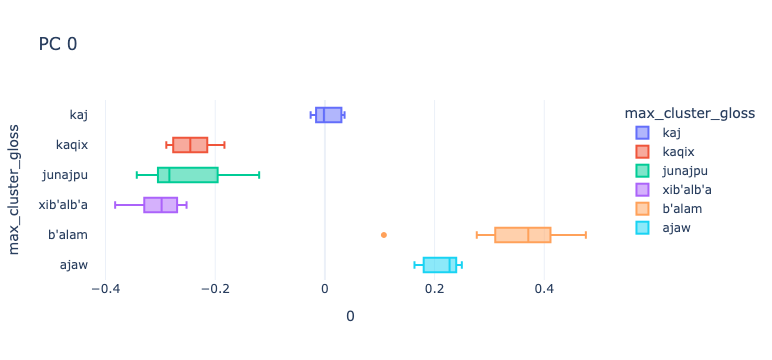

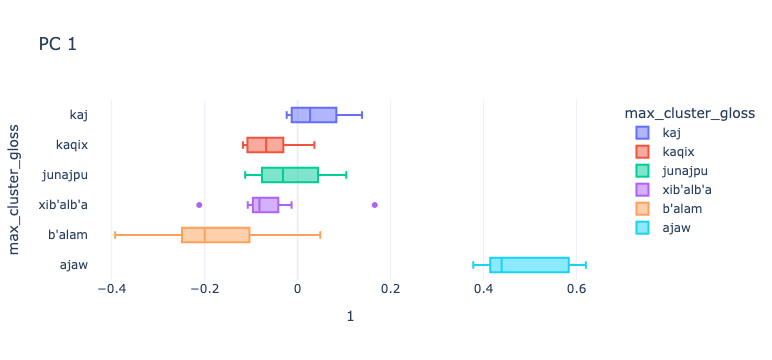

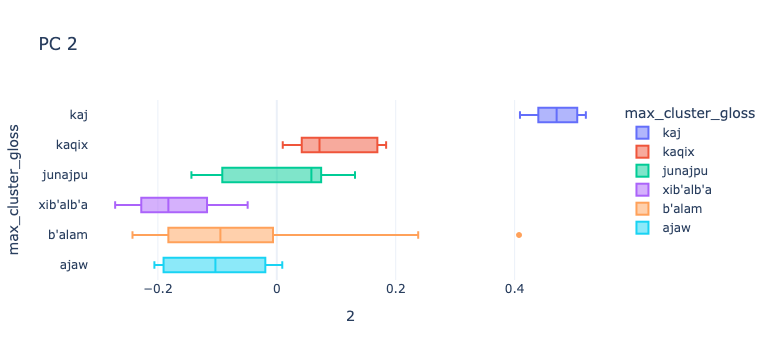

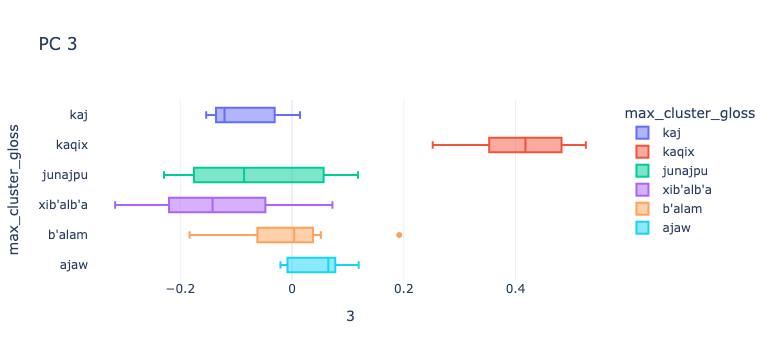

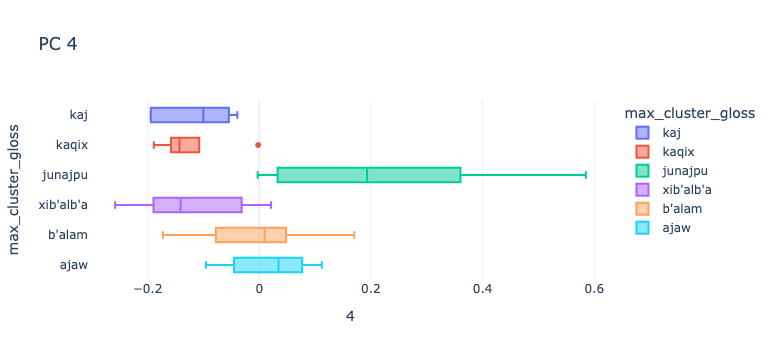

In [185]:
for i in range(n_comps):
    comp_box(i)

# Generate NMF model

Topic modeling with NMF gives further insight into the content of the clusters and how they combine in documents, i.e. units of narrative.

As a form of soft clustering, it lends insight into how each text segment relates to each cluster.

It also corroborates the clustering.

**Choose $k$ based on cluster threshold**

We choose $k$ based on the chosen cut-off threshold for the clustering above.

In [186]:
k = len(set(tfidf_hac.CLUSTER_LABELS))
k

6

Create a list of columns for selection operations.

In [187]:
k_cols = [i for i in range(k)]

In [188]:
n_topic_terms = 10
nmf_engine = NMF(n_components=k, max_iter=5000, init='nndsvda', solver='mu', beta_loss='kullback-leibler')
THETA = pd.DataFrame(nmf_engine.fit_transform(TFIDF), index=TFIDF.index)
THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)
PHI = pd.DataFrame(nmf_engine.components_, columns=TFIDF.columns)
TOPIC = PHI.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_topic_terms).index)).T.to_frame('top_terms')
TOPIC.index.name = 'topic_id'
CHUNK[f'top_topic_{k}'] = THETA.idxmax(1).values

In [189]:
with open("topics.md", "w") as outfile:
    TOPIC.to_markdown(outfile)

In [190]:
TOPIC['gloss'] = PHI.idxmax(1)

In [191]:
TOPIC

,top_terms,gloss
topic_id,,
0,"b'alam, amaq, tojil, kitze, majukutaj, k'ab'aw...",b'alam
1,"kame, xib'alb'a, junajpu, xcha, kik, b'a, ajaw...",kame
2,"ajaw, ajawab, pop, tinamit, aj, nim, k'iche, q...",ajaw
3,"kaj, b'it, winaq, tz'aq, ulew, aj, k'ajolom, a...",kaj
4,"kaqix, k'ajolab, sipakna, wuqub, jul, kab'raqa...",kaqix
5,"kati't, chowen, ati't, junajpu, b'atz, qati't,...",kati't


# Compare to clusters

In [192]:
CLUSTER.sort_values('gloss')

,n_chunks,ord,gloss,top_terms
cluster_label,,,,
5,7,6,ajaw,"ajaw, ajawab, tinamit, aj, pop, nim, k'iche"
4,14,5,b'alam,"b'alam, amaq, tojil, kitze, majukutaj, aj, aq'ab"
3,10,3,junajpu,"junajpu, q'apoj, chowen, kati't, che, b'atz, kame"
6,5,1,kaj,"kaj, b'it, winaq, tz'aq, ulew, tio'jil, aj"
1,5,2,kaqix,"kaqix, k'ajolab, sipakna, wuqub, jul, kab'raqa..."
2,9,4,xib'alb'a,"xib'alb'a, kame, xcha, b'a, k'ajolab, k'ate, naqi"


# View topics over syuzhet

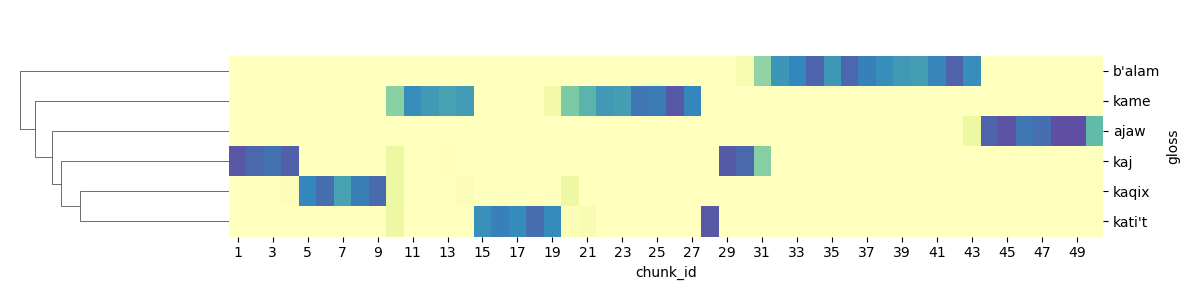

In [193]:
THETA.columns = TOPIC.gloss
fig = sns.clustermap(THETA.T, 
                     cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                    figsize=(12,3))

# Classify chapters with NMF model

In [194]:
# This is slow ...
# CHAP['max_topic_test'] = (
#     BOW_CHAP.to_frame('tf')
#     .join(PHI.T, on='term_str')
#     .apply(lambda x: x.tf * x[k_cols], axis=1)
#     .dropna()
#     .groupby('chap_num')
#     .mean()
#     .idxmax(1)
# )

In [195]:
CHAP_TOPIC = (
    TOKEN
    .join(PHI.T, on='term_str')
    .dropna()
    .groupby(['chap_num'])[k_cols]
    .mean()
)

In [196]:
CHAP_TOPIC

,0,1,2,3,4,5
chap_num,,,,,,
1,0.036181,0.027976,0.058814,0.117819,0.026926,0.033587
2,0.039604,0.044268,0.042167,0.109433,0.043682,0.036201
3,0.034352,0.028819,0.043354,0.120400,0.044471,0.027465
4,0.049743,0.037184,0.031629,0.079061,0.052529,0.062027
5,0.046681,0.043828,0.023244,0.111381,0.045253,0.047633
...,...,...,...,...,...,...
83,0.044303,0.022324,0.145896,0.044882,0.022858,0.015602
84,0.053454,0.050592,0.234741,0.048018,0.032839,0.033577
85,0.081495,0.059334,0.197901,0.089164,0.061526,0.040694


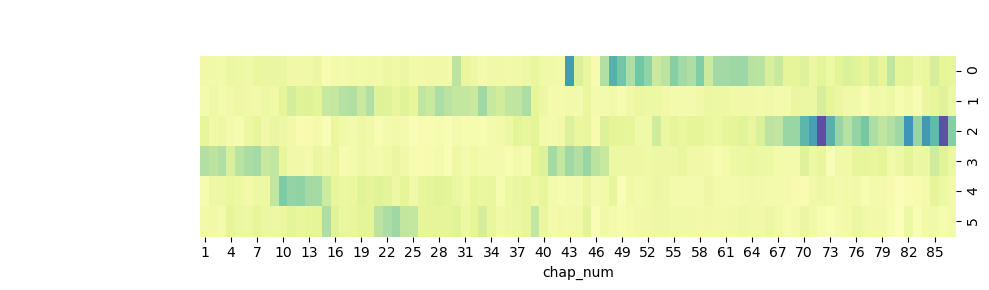

In [197]:
sns.clustermap(CHAP_TOPIC.T, 
                     cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=False, 
                     col_cluster=False,
                    figsize=(10,3));

In [198]:
CHAP['max_topic'] = CHAP_TOPIC[k_cols].idxmax(1)
CHAP['max_topic_gloss'] = CHAP.max_topic.map(TOPIC.gloss)

In [199]:
CHAP[['chap_title', 'max_topic_gloss', 'max_topic', 'cluster_label', 'max_cluster']].style.background_gradient(cmap='YlGnBu')

,chap_title,max_topic_gloss,max_topic,cluster_label,max_cluster
chap_num,,,,,
1,Preamble,kaj,3,6,6
2,The Primordial World,kaj,3,6,6
3,The Creation of the Earth,kaj,3,6,6
4,The Creation of the Animals,kaj,3,6,6
5,The Fall of the Animals,kaj,3,6,6
6,The Creation of the Mud Person,kaj,3,6,6
7,The Creation of the Effigies of Carved Wood,kaj,3,6,6
8,The Fall of the Effigies of Carved Wood,kaj,3,6,6
9,The Pride of Seven Macaw Before the Dawn,kaj,3,6,6


# Correlation Sequence

In [218]:
R = THETA.T.corr('pearson').stack().sort_index().to_frame('r')

In [219]:
R.index.names = ['chunk_id_tmp', 'chunk_id']

In [220]:
RDIFF = R.query("chunk_id == chunk_id_tmp + 1") #.plot.barh(figsize=(2,10), legend=False);
RDIFF = RDIFF.reset_index().set_index('chunk_id').drop(columns=['chunk_id_tmp'])

In [221]:
RDIFF.style.bar()

,r
chunk_id,
2,1.000000
3,1.000000
4,0.999328
5,-0.163944
6,1.000000
7,1.000000
8,1.000000
9,1.000000
10,-0.030643


In [204]:
CHUNK['rdiff'] = RDIFF

In [205]:
CHUNK[['long_label','max_cluster','rdiff']].style.background_gradient()

,long_label,max_cluster,rdiff
chunk_id,,,
1,[1] 1: Preamble 2: The Primordial World 3: The Creation of the Earth,6,nan
2,[2] 3: The Creation of the Earth 4: The Creation of the Animals 5: The Fall of the Animals 6: The Creation of the Mud Person,6,1.000000
3,[3] 6: The Creation of the Mud Person 7: The Creation of the Effigies of Carved Wood 8: The Fall of the Effigies of Carved Wood,6,1.000000
4,[4] 8: The Fall of the Effigies of Carved Wood 9: The Pride of Seven Macaw Before the Dawn,6,0.999328
5,[5] 9: The Pride of Seven Macaw Before the Dawn 10: The Fall of Seven Macaw and His Sons 11: The Defeat of Seven Macaw,1,-0.163944
6,[6] 11: The Defeat of Seven Macaw 12: The Deeds of Zipacna and the Four Hundred Boys,1,1.000000
7,[7] 12: The Deeds of Zipacna and the Four Hundred Boys,1,1.000000
8,[8] 12: The Deeds of Zipacna and the Four Hundred Boys 13: The Defeat of Zipacna,1,1.000000
9,[9] 13: The Defeat of Zipacna 14: The Defeat of Cabracan,1,1.000000


# Conclusion
**UPDATE TO INCLUDE CLASSIFICATION**

- Six chapters
- The text is divided into two major parts, corresponding to before and after the first dawn.
- Each major part has three parts: Creation, Part A, and Part B.
- The goings on in Xibalba have the moist variability.
- Proposed structure: 6 parts with a preamble and a coda.
- Each part is distinguished temporally and ontologically.
- The sequence matters: We go from the creation of the world to the creation of society.
- The sequence charts a lineage from the K'iche' kings to the creator gods. 

# Save

In [206]:
savers = [
    (TFIDF, 'TFIDF'),
    (TFIDF_SIM, 'TFIDF_SIM')
]

In [207]:
for saver in savers:
    obj = saver[0]
    slug = saver[1]
    obj.to_csv(f"christenson-{slug}.csv", index=True)